In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import ttest_ind
from scipy.stats import f_oneway
from scipy.stats import pearsonr
from scipy.stats import shapiro

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings('ignore')

In [3]:
# Load datasets
sales_df = pd.read_csv('sales_data.csv')
churn_df = pd.read_csv('customer_churn.csv')

print("Sales Dataset Shape:", sales_df.shape)
print("Customer Churn Dataset Shape:", churn_df.shape)

print("\nSales Dataset Preview")
print(sales_df.head())

print("\nCustomer Churn Dataset Preview")
print(churn_df.head())

Sales Dataset Shape: (100, 7)
Customer Churn Dataset Shape: (500, 9)

Sales Dataset Preview
         Date     Product  Quantity  Price Customer_ID Region  Total_Sales
0  2024-01-01       Phone         7  37300     CUST001   East       261100
1  2024-01-02  Headphones         4  15406     CUST002  North        61624
2  2024-01-03       Phone         2  21746     CUST003   West        43492
3  2024-01-04  Headphones         1  30895     CUST004   East        30895
4  2024-01-05      Laptop         8  39835     CUST005  North       318680

Customer Churn Dataset Preview
  CustomerID  Tenure  MonthlyCharges  TotalCharges        Contract  \
0     C00001       6              64          1540        One year   
1     C00002      21             113          1753  Month-to-month   
2     C00003      27              31          1455        Two year   
3     C00004      53              29          7150  Month-to-month   
4     C00005      16             185          1023        One year   

     

In [4]:
print(sales_df.info())

print("\nMissing Values:\n")
print(sales_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         100 non-null    object
 1   Product      100 non-null    object
 2   Quantity     100 non-null    int64 
 3   Price        100 non-null    int64 
 4   Customer_ID  100 non-null    object
 5   Region       100 non-null    object
 6   Total_Sales  100 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 5.6+ KB
None

Missing Values:

Date           0
Product        0
Quantity       0
Price          0
Customer_ID    0
Region         0
Total_Sales    0
dtype: int64


In [5]:
# Fill numeric missing values with mean

numeric_cols = sales_df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    sales_df[col].fillna(sales_df[col].mean(), inplace=True)

print("Missing values handled successfully!")

Missing values handled successfully!


In [6]:
print("DESCRIPTIVE STATISTICS")
print("-" * 40)

print(sales_df.describe())

DESCRIPTIVE STATISTICS
----------------------------------------
         Quantity         Price    Total_Sales
count  100.000000    100.000000     100.000000
mean     4.780000  25808.510000  123650.480000
std      2.588163  13917.630242  100161.085275
min      1.000000   1308.000000    6540.000000
25%      2.750000  14965.250000   39517.500000
50%      5.000000  24192.000000   97955.500000
75%      7.000000  38682.250000  175792.500000
max      9.000000  49930.000000  373932.000000


In [7]:
numeric_data = sales_df.select_dtypes(include=np.number)

for col in numeric_data.columns:
    
    print(f"\nColumn: {col}")
    print(f"Mean: {numeric_data[col].mean():.2f}")
    print(f"Median: {numeric_data[col].median():.2f}")
    print(f"Mode: {numeric_data[col].mode()[0]:.2f}")
    print(f"Standard Deviation: {numeric_data[col].std():.2f}")


Column: Quantity
Mean: 4.78
Median: 5.00
Mode: 4.00
Standard Deviation: 2.59

Column: Price
Mean: 25808.51
Median: 24192.00
Mode: 1308.00
Standard Deviation: 13917.63

Column: Total_Sales
Mean: 123650.48
Median: 97955.50
Mode: 6540.00
Standard Deviation: 100161.09


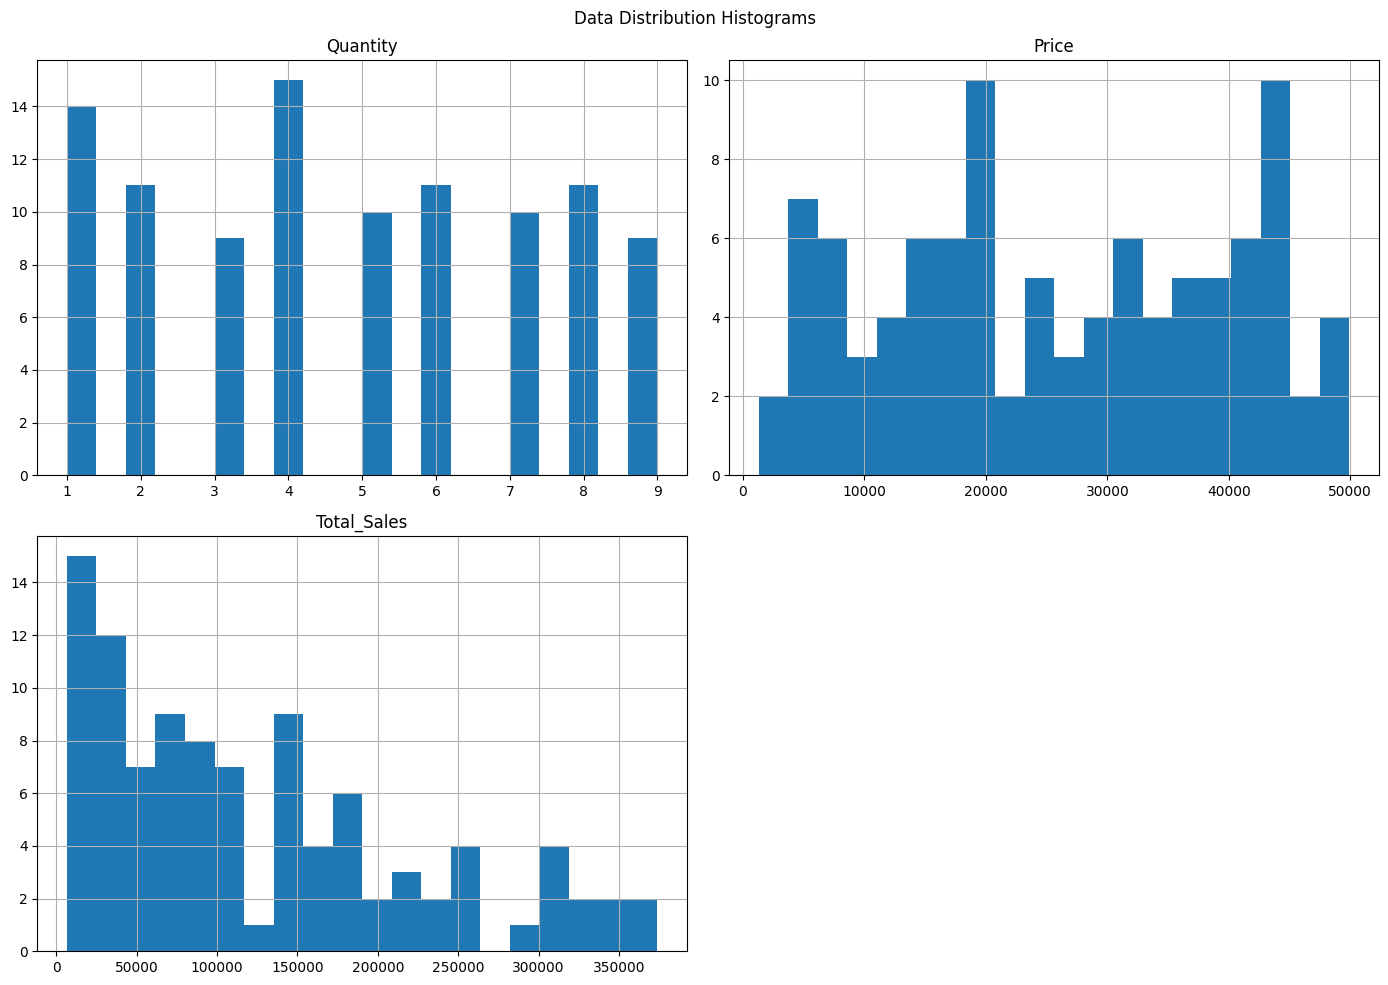

In [8]:
numeric_data.hist(figsize=(14,10), bins=20)

plt.suptitle("Data Distribution Histograms")
plt.tight_layout()
plt.show()

In [9]:
print("SHAPIRO-WILK NORMALITY TEST")
print("-" * 40)

for col in numeric_data.columns:
    
    stat, p = shapiro(
        numeric_data[col].sample(
            min(500, len(numeric_data))
        )
    )

    print(f"\n{col}")
    print(f"Statistic: {stat:.4f}")
    print(f"P-value: {p:.4f}")

    if p > 0.05:
        print("Data appears normally distributed")
    else:
        print("Data is NOT normally distributed")

SHAPIRO-WILK NORMALITY TEST
----------------------------------------

Quantity
Statistic: 0.9304
P-value: 0.0001
Data is NOT normally distributed

Price
Statistic: 0.9475
P-value: 0.0006
Data is NOT normally distributed

Total_Sales
Statistic: 0.8989
P-value: 0.0000
Data is NOT normally distributed


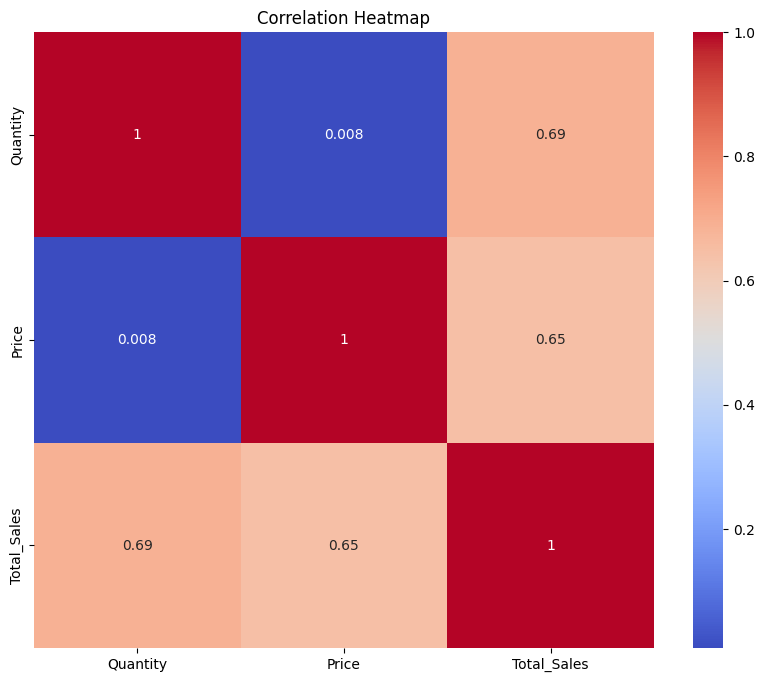

In [10]:
correlation_matrix = numeric_data.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

In [11]:
# Correlation between Price and Total_Sales

corr, p_value = pearsonr(
    sales_df['Price'],
    sales_df['Total_Sales']
)

print("PEARSON CORRELATION ANALYSIS")
print("-" * 40)

print(f"Correlation Coefficient: {corr:.4f}")
print(f"P-value: {p_value:.4f}")

if abs(corr) > 0.7:
    print("Strong Correlation")

elif abs(corr) > 0.4:
    print("Moderate Correlation")

else:
    print("Weak Correlation")

PEARSON CORRELATION ANALYSIS
----------------------------------------
Correlation Coefficient: 0.6461
P-value: 0.0000
Moderate Correlation


In [12]:
# Compare East and West region sales

east_sales = sales_df[
    sales_df['Region'] == 'East'
]['Total_Sales']

west_sales = sales_df[
    sales_df['Region'] == 'West'
]['Total_Sales']

stat, p = ttest_ind(
    east_sales,
    west_sales
)

print("HYPOTHESIS TEST 1 – T-TEST")
print("-" * 40)

print(f"T-statistic: {stat:.4f}")
print(f"P-value: {p:.4f}")

if p < 0.05:
    print("Significant difference found")

else:
    print("No significant difference")

HYPOTHESIS TEST 1 – T-TEST
----------------------------------------
T-statistic: 2.0202
P-value: 0.0496
Significant difference found


In [13]:
north_sales = sales_df[
    sales_df['Region'] == 'North'
]['Total_Sales']

south_sales = sales_df[
    sales_df['Region'] == 'South'
]['Total_Sales']

east_sales = sales_df[
    sales_df['Region'] == 'East'
]['Total_Sales']

west_sales = sales_df[
    sales_df['Region'] == 'West'
]['Total_Sales']

f_stat, p = f_oneway(
    north_sales,
    south_sales,
    east_sales,
    west_sales
)

print("HYPOTHESIS TEST 2 – ANOVA")
print("-" * 40)

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p:.4f}")

if p < 0.05:
    print("Significant differences exist")

else:
    print("No significant differences")

HYPOTHESIS TEST 2 – ANOVA
----------------------------------------
F-statistic: 2.1644
P-value: 0.0972
No significant differences


In [14]:
print("HYPOTHESIS TEST 3")
print("-" * 40)

if p_value < 0.05:
    print("Correlation is statistically significant")

else:
    print("Correlation is NOT statistically significant")

HYPOTHESIS TEST 3
----------------------------------------
Correlation is statistically significant


In [15]:
confidence_level = 0.95

for col in numeric_data.columns:

    data = numeric_data[col]

    mean = np.mean(data)

    sem = stats.sem(data)

    margin = sem * stats.t.ppf(
        (1 + confidence_level) / 2.,
        len(data)-1
    )

    lower = mean - margin
    upper = mean + margin

    print(f"\nColumn: {col}")

    print(f"Mean: {mean:.2f}")

    print(
        f"95% Confidence Interval: "
        f"({lower:.2f}, {upper:.2f})"
    )

    print(f"Margin of Error: ±{margin:.2f}")


Column: Quantity
Mean: 4.78
95% Confidence Interval: (4.27, 5.29)
Margin of Error: ±0.51

Column: Price
Mean: 25808.51
95% Confidence Interval: (23046.95, 28570.07)
Margin of Error: ±2761.56

Column: Total_Sales
Mean: 123650.48
95% Confidence Interval: (103776.35, 143524.61)
Margin of Error: ±19874.13


In [16]:
# Predict Total Sales using Price

X = sales_df[['Price']]

y = sales_df['Total_Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)

print("LINEAR REGRESSION ANALYSIS")
print("-" * 40)

print(f"Intercept: {model.intercept_:.4f}")

print(f"Coefficient: {model.coef_[0]:.4f}")

print(f"R-squared Score: {r2:.4f}")

LINEAR REGRESSION ANALYSIS
----------------------------------------
Intercept: -872.5339
Coefficient: 4.7532
R-squared Score: 0.3599


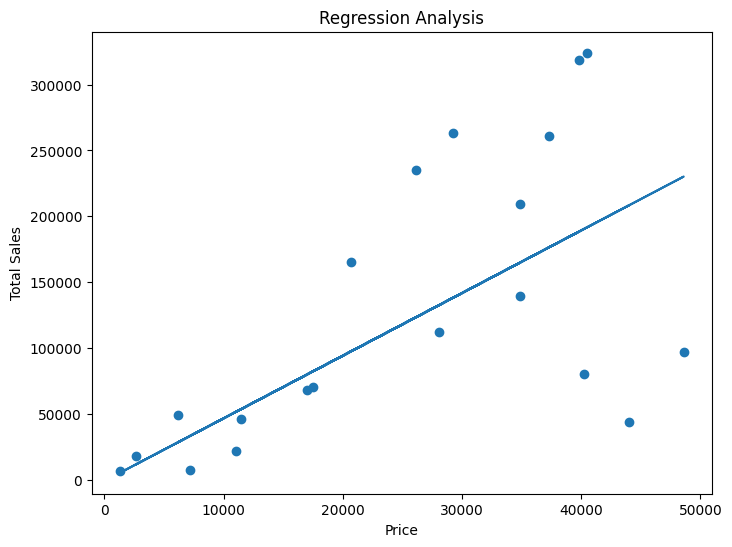

In [17]:
plt.figure(figsize=(8,6))

plt.scatter(X_test, y_test)

plt.plot(X_test, y_pred)

plt.xlabel("Price")

plt.ylabel("Total Sales")

plt.title("Regression Analysis")

plt.show()

In [18]:
print("STATISTICAL ANALYSIS REPORT")

print("=" * 50)

avg_sales = sales_df['Total_Sales'].mean()

print(f"Average Sales: {avg_sales:.2f}")

print(
    f"Correlation (Price-Total Sales): "
    f"{corr:.2f}"
)

print(f"R-Squared Value: {r2:.2f}")

if p_value < 0.05:
    print("Price significantly affects sales")

else:
    print("Price does not significantly affect sales")

print("\nBUSINESS RECOMMENDATIONS")

print("-" * 40)

print("1. Focus on high-performing regions")

print("2. Optimize product pricing")

print("3. Use regression forecasting")

print("4. Monitor customer churn")

print("5. Continue data-driven decision making")

STATISTICAL ANALYSIS REPORT
Average Sales: 123650.48
Correlation (Price-Total Sales): 0.65
R-Squared Value: 0.36
Price significantly affects sales

BUSINESS RECOMMENDATIONS
----------------------------------------
1. Focus on high-performing regions
2. Optimize product pricing
3. Use regression forecasting
4. Monitor customer churn
5. Continue data-driven decision making


In [19]:
with open(
    'hypothesis_tests_results.txt',
    'w'
) as file:

    file.write(
        "HYPOTHESIS TEST RESULTS\n"
    )

    file.write("=" * 40 + "\n\n")

    file.write("T-Test Results\n")

    file.write(
        f"T-statistic: {stat:.4f}\n"
    )

    file.write(
        f"P-value: {p:.4f}\n\n"
    )

    file.write("Correlation Test\n")

    file.write(
        f"Correlation: {corr:.4f}\n"
    )

    file.write(
        f"P-value: {p_value:.4f}\n\n"
    )

    file.write("Regression Analysis\n")

    file.write(
        f"R-squared Score: {r2:.4f}\n"
    )

print("Results saved successfully!")

Results saved successfully!
